# 🧩 Build Custom Conformal Methods with *puncc*

This tutorial shows how to conformalize your models by plugging your own idea for nonconformity score and calibration workflow.

We start with the most common workflow: split conformal prediction with custom nonconformity score functions passed directly as arguments. Then we move to the advanced API, where the conformalization logic is defined explicitly through the `BaseCalibrator` object.

In the examples below, we will illustrate those possibilities by conformalizing a model to produce **constant size prediction intervals** and **kernel-based prediction intervals**. 

**Table of contents**

- [⚙️ Setup](#custom-setup)
- [💾 Dataset](#custom-data)
- [🔮 Predictor](#custom-model)
- [⏸️ Common case with `SplitConformalPredictor`](#custom-splitcp)
- [🧱 Advanced API: explicit calibrator](#custom-advanced)

**Links**
- [<img src="https://github.githubassets.com/images/icons/emoji/octocat.png" width=20> Github](https://github.com/deel-ai/puncc)
- [📘 Documentation](https://deel-ai.github.io/puncc/index.html)


In [1]:
# If you run this notebook in a fresh environment, uncomment:
#!pip install puncc torch

### ⚙️ Setup <a class="anchor" id="custom-setup"></a>

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch

from deel.puncc.api.conformalization import SplitConformalPredictor
from deel.puncc.metrics import regression_mean_coverage, regression_sharpness
from deel.puncc.plotting import plot_prediction_intervals

warnings.filterwarnings("ignore")

np.random.seed(0)
torch.manual_seed(0)


def make_tensor(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 1:
        x = x[:, None]
    return torch.tensor(x, dtype=torch.float32)


def evaluate_intervals(name, y_true, y_pred, y_lower, y_upper):
    y_true_np = y_true.cpu().numpy().reshape(-1)
    y_pred_np = y_pred.cpu().numpy().reshape(-1)
    y_lower_np = y_lower.cpu().numpy().reshape(-1)
    y_upper_np = y_upper.cpu().numpy().reshape(-1)

    return {
        "method": name,
        "coverage": round(
            float(regression_mean_coverage(y_true_np, y_lower_np, y_upper_np)),
            3,
        ),
        "avg_width": round(
            float(regression_sharpness(y_lower_np, y_upper_np)), 3
        ),
        "mean_prediction": round(float(np.mean(y_pred_np)), 3),
    }

### 💾 Dataset <a class="anchor" id="custom-data"></a>

We build a one-dimensional heteroskedastic regression problem where the noise level grows with the input.

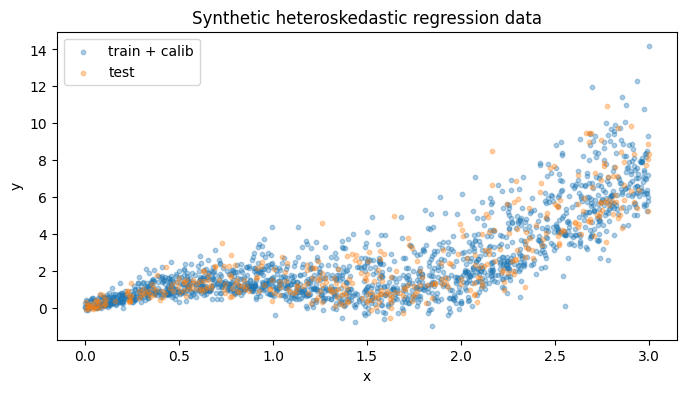

In [2]:
torch.manual_seed(0)

n = 2000

X = torch.empty(n, 1, dtype=torch.float32).uniform_(0, 3.0)
noise_scale = 0.2 + 0.8 * (X[:, 0])
signal = 0.7 * X[:, 0] ** 2 + torch.sin(2.5 * X[:, 0])
noise = torch.normal(mean=0.0, std=noise_scale)
noise = torch.where(noise > 0, noise, noise / 2)
y = signal + noise

g0 = torch.Generator().manual_seed(0)
perm = torch.randperm(n, generator=g0)

n_test = int(0.2 * n)
test_idx = perm[:n_test]
train_idx = perm[n_test:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

g1 = torch.Generator().manual_seed(1)
perm_train = torch.randperm(X_train.shape[0], generator=g1)

n_calib = int(0.5 * X_train.shape[0])
calib_idx = perm_train[:n_calib]
fit_idx = perm_train[n_calib:]

X_fit, X_calib = X_train[fit_idx], X_train[calib_idx]
y_fit, y_calib = y_train[fit_idx], y_train[calib_idx]

X_fit_t = X_fit
X_calib_t = X_calib
X_test_t = X_test
X_train_t = X_train

y_fit_t = y_fit.unsqueeze(1)
y_calib_t = y_calib.unsqueeze(1)
y_train_t = y_train.unsqueeze(1)

plt.figure(figsize=(8, 4))
plt.scatter(X_train[:, 0], y_train, s=10, alpha=0.35, label="train + calib")
plt.scatter(X_test[:, 0], y_test, s=10, alpha=0.35, label="test")
plt.title("Synthetic heteroskedastic regression data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

### 🔮 Predictor <a class="anchor" id="custom-model"></a>

Let's build a Pytorch base model and keep it intentionally simple. The goal is not model design but how to attach custom conformal logic to our PyTorch regressor.

In [3]:
class RegressionNet(torch.nn.Module):
    def __init__(self, lr=1e-2):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(1, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
        )
        self.lr = lr
        self.loss = torch.nn.MSELoss(reduction="mean")

    def forward(self, x):
        return self.model(x)

    def fit(self, X, y, epochs=250, **kwargs):
        del kwargs
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        self.model.train()
        for _ in range(epochs):
            y_pred = self.model(X)
            loss = self.loss(y_pred, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if _ % 50 == 0:
                print(f"Epoch {_}: loss={loss.item():.4f}")

    def predict(self, X, **kwargs):
        del kwargs
        self.model.eval()
        with torch.no_grad():
            return self.model(X)

### ⏸️ Common case: `SplitConformalPredictor` <a class="anchor" id="custom-splitcp"></a>

The simplest way to build a new split conformal regressor in *puncc* is to pass a custom score and a custom prediction-set directly to `SplitConformalPredictor`.

Here we define custom quadratic nonconformity score (calibration), associated prediction set (inference) and plug them in the constructor.
By default, the nonconformity score function take as arguments the model predictions `y_pred` and the ground true labels `y_true`; while the prediction set function requires the model predictions `y_pred` and the quantile of nonconformity scores. Internally, puncc will handle all conformalization logic if the function signatures are respected. Here is the example:

In [4]:
from deel.puncc.api.prediction import BasePredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch_model = RegressionNet().to(device)

split_cp = SplitConformalPredictor(
    predictor=BasePredictor(torch_model),
    nonconf_score_func=lambda y_pred, y_true: torch.square(
        y_pred - y_true
    ),  # custom nonconformity score function
    pred_set_func=lambda y_pred, scores_quantile: (  # custom prediction set function
        y_pred - torch.sqrt(torch.tensor(scores_quantile, device=device)),
        y_pred + torch.sqrt(torch.tensor(scores_quantile, device=device)),
    ),
    train=True,
    random_state=0,
)

split_cp.fit(
    X_fit=X_fit_t.to(device),
    y_fit=y_fit_t.to(device),
    X_calib=X_calib_t.to(device),
    y_calib=y_calib_t.to(device),
    epochs=300,
)

Epoch 0: loss=11.2856
Epoch 50: loss=1.8211
Epoch 100: loss=1.3692
Epoch 150: loss=1.2958
Epoch 200: loss=1.2867
Epoch 250: loss=1.2858


We can now evaluate the performance of the prediction intervals (average coverage and width) for a error level $\alpha = 10\%$. Additionally, we will plot the prediction intervals to visually assess their performance.

{'method': 'custom split conformal', 'coverage': 0.998, 'avg_width': 10.826, 'mean_prediction': 2.472}


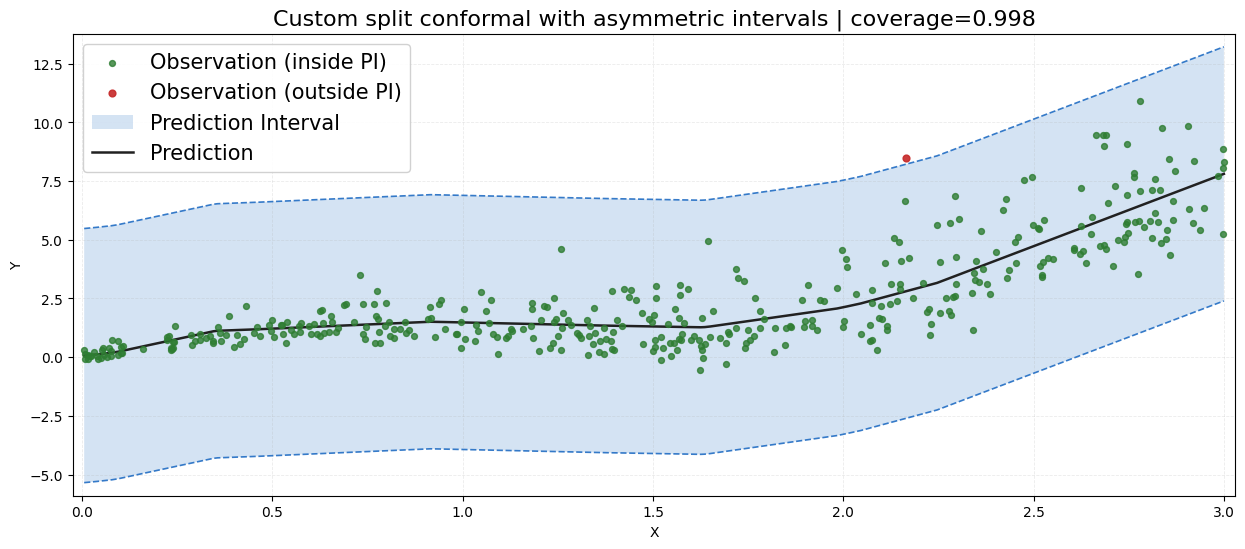

In [5]:
alpha = 0.1

y_pred_split, y_lower_split, y_upper_split = split_cp.predict(
    X_test_t.to(device), alpha=alpha
)

split_summary = evaluate_intervals(
    "custom split conformal",
    y_test,
    y_pred_split,
    y_lower_split,
    y_upper_split,
)

print(split_summary)

plot_prediction_intervals(
    y_test.cpu().numpy(),
    y_lower_split.cpu().numpy(),
    y_upper_split.cpu().numpy(),
    X=X_test.cpu().numpy()[:, 0],
    y_pred=y_pred_split.cpu().numpy(),
    title="Custom split conformal with asymmetric intervals",
)
plt.show()

### 🧱 Advanced API: explicit calibrator <a class="anchor" id="custom-advanced"></a>

Notice that noise scale increases with X. We can then be motivated to define a kernel/scale-based nonconformity scores, that encodes this expert knowledge (be careful about information leakage). 

In [6]:
# Custom kernel-based nonconformity score function
def kernel_nonconformity_score(X, y_pred, y_true, weight_func):
    residuals = torch.abs(y_pred - y_true)
    weights = weight_func(X)
    weighted_residuals = residuals * weights
    return weighted_residuals


# Custom kernel-based prediction set function
def kernel_prediction_set(y_pred, scores_quantile, weights):
    lower_bound = (
        y_pred - torch.tensor(scores_quantile, device=y_pred.device) / weights
    )
    upper_bound = (
        y_pred + torch.tensor(scores_quantile, device=y_pred.device) / weights
    )
    return lower_bound, upper_bound

In the current implementation, nonconformity score function does not natively rely on the features X. In this situation, we need to adjust the conformalization logic to account for this need. We will first update the workflow for computing nonconformity scores, which mainly lives in `BaseCalibrator`. Then plug it all together into the `SplitConformalPredictor`. 

In practice:

1) we will subclass `deel.puncc.api.calibration.BaseCalibrator` and adapt the two class methods:
    - `fit(...)`: called during calibration. Its job is to compute and store the nonconformity scores on the calibration set.
    - `calibrate(...)`: called during inference. Its job is to build prediction sets for new samples.
2) Then, the newly defined calibrator class is provided to the `SplitCOnformalPredictor` constructor as argument.

`SplitConformalPredictor` remains useful here. We do not rewrite the whole split conformal workflow. We only replace the calibrator class through `CalibratorClass`.
This is the important design point: subclass the smallest component that needs to change. The predictor training, fit/calibration split handling, quantile computation, and prediction workflow can still be delegated to PUNCC.

⚠️Note: if the user wants to also provide a new selection scheme for the calibration data, we recommend the [API tutorial](https://github.com/deel-ai/puncc/blob/main/docs/api_intro.ipynb) for more details.

In [7]:
from deel.puncc.api.calibration import BaseCalibrator


# Custom kernel-based calibrator class
class KernelCalibrator(BaseCalibrator):
    def __init__(
        self, *, nonconf_score_func, pred_set_func, kernel_func, **kwargs
    ):
        super().__init__(
            nonconf_score_func=nonconf_score_func,
            pred_set_func=pred_set_func,
        )
        self.kernel_func = (
            kernel_func  # we add a kernel function to the calibrator class
        )

    def fit(
        self, *, X, y_true, y_pred, **kwargs
    ):  # we add the features X as an argument to the fit method
        self._residuals = self.nonconf_score_func(
            X, y_pred, y_true, weight_func=self.kernel_func
        )
        self._len_calib = len(self._residuals)

    def calibrate(self, *, alpha, X, y_pred, **kwargs):
        residuals_Q = self.compute_quantile(alpha=alpha)
        return self.pred_set_func(
            y_pred,
            scores_quantile=residuals_Q,
            weights=1
            / self.kernel_func(
                X
            ),  # we adapt the call to the prediction set function to include the weights computed from the kernel function
        )


# Custom kernel-based split conformal predictor
kernel_splitcp = SplitConformalPredictor(
    predictor=BasePredictor(torch_model),
    nonconf_score_func=kernel_nonconformity_score,
    pred_set_func=kernel_prediction_set,
    CalibratorClass=lambda **kwargs: KernelCalibrator(
        kernel_func=lambda X: torch.log(X[:, 0] + 1) / 2 + 0.1, **kwargs
    ),  # provide a calibrator subclass as an argument to the SplitConformalPredictor
)

kernel_splitcp.fit(
    X_fit=X_fit_t.to(device),
    y_fit=y_fit_t.to(device),
    X_calib=X_calib_t.to(device),
    y_calib=y_calib_t.to(device),
    epochs=400,
)

Epoch 0: loss=1.2856
Epoch 50: loss=1.2875
Epoch 100: loss=1.2856
Epoch 150: loss=1.2855
Epoch 200: loss=1.2853
Epoch 250: loss=1.2853
Epoch 300: loss=1.2852
Epoch 350: loss=1.2851


Finally, we evaluate and visualize the performance of the prediction intervals for a error level $\alpha = 10\%$. 

{'method': 'custom split conformal', 'coverage': 0.94, 'avg_width': 3.672, 'mean_prediction': 2.48}


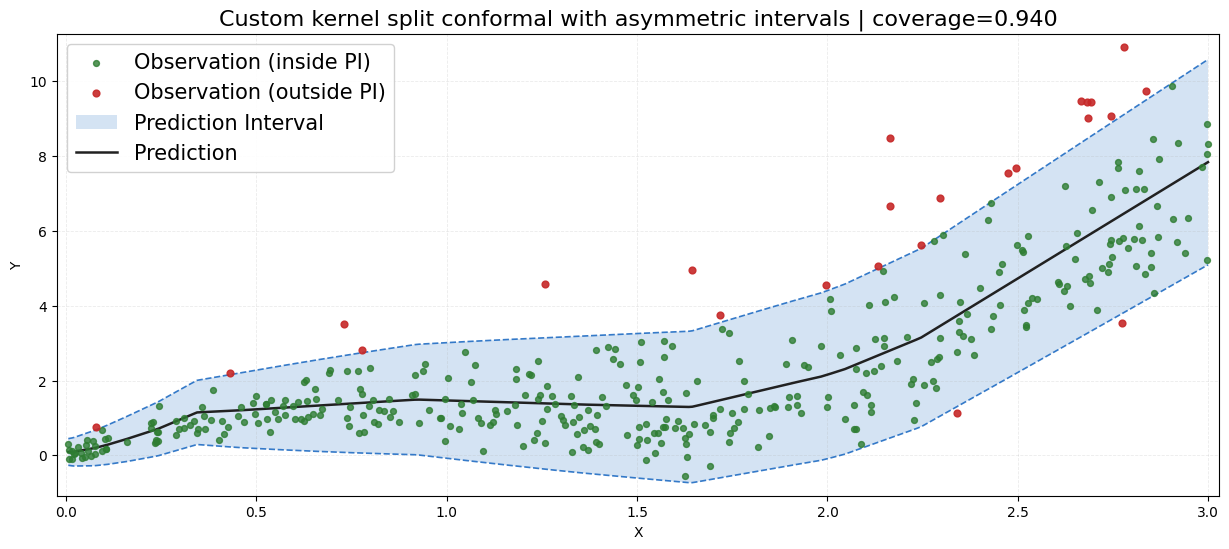

In [8]:
alpha = 0.1

y_pred_split, y_lower_split, y_upper_split = kernel_splitcp.predict(
    X_test_t.to(device), alpha=alpha
)

split_summary = evaluate_intervals(
    "custom split conformal",
    y_test,
    y_pred_split,
    y_lower_split,
    y_upper_split,
)

print(split_summary)

plot_prediction_intervals(
    y_test.cpu().numpy(),
    y_lower_split.cpu().numpy(),
    y_upper_split.cpu().numpy(),
    X=X_test.cpu().numpy()[:, 0],
    y_pred=y_pred_split.cpu().numpy(),
    title="Custom kernel split conformal with asymmetric intervals",
)
plt.show()

## Takeaways

PUNCC lets you customize conformal methods progressively.

1. If you only need a new score and a new prediction-set function, pass them directly to `SplitConformalPredictor`.
2. If the score and/or prediction set need special arguments/logic, subclass `BaseCalibrator`.
3. In a custom calibrator, adapt `fit(...)` and `calibrate(...)` to account for the changes in the conformalization workflow.
5. Change only the component that needs to change. In most cases, PUNCC can still manage splitting, training orchestration, prediction calls, and quantile computation.

For more details on the architecture behind these components its API, see [Architecture tutorial](puncc_architecture.ipynb) and [API tutorial](https://github.com/deel-ai/puncc/blob/main/docs/api_intro.ipynb).